# Using Machine Learning to Integrate Customer Segmentation, Churn Prediction and Return Prediction in Online Retail

**Capstone Project Notebook**


## Introduction

Online retailers gather a lot of information about the purchases their customers make.However, this data is not always used to understand customer behaviour. This project focuses on three main questions:  

- **Who are our customers?** Customers have different shopping behavior, but businesses often treat them in the same way.
- **Who is about to stop shopping with us?** A customer may slowly stop buying before the business notices that they are leaving.
- **Who is likely to return what they bought?** Product returns can cost a business money, so it is useful to understand which customers are most likely to return items.

These three problems are often studied separately. This project combines them into one analysis using online retail dataset.This project has three main parts:

1. **Customer Segmentation** - group customers based on how recently they purchased, how often they purchase, and how much they spend (RFM + K-Means).
2. **Churn Prediction** - predict which customers may stop buying.
3. **Return Prediction** - predict which customers are most likely to return an item.

The main idea of this project is to bring these three areas together in one machine learning pipeline and use the results to provide useful information for a retailer.


## Objectives

- Clean and prepare the Online Retail II dataset for analysis.
- Engineer Recency, Frequency and Monetary (RFM) features, return features, and a churn label for each customer.
- Group customers into segments using K-Means clustering.
- Build and compare models that predict customer churn.
- Build and compare models that predict customer returns.
- Evaluate every model using Accuracy, Precision, Recall and F1-Score.
- Turn the results into business recommendations a retailer could actually act on.

## Notebook Structure

| Phase | What happens |
|---|---|
| 1 | Import Libraries |
| 2 | Load Dataset |
| 3 | Exploratory Data Analysis |
| 4 | Data Cleaning |
| 5 | Feature Engineering (TotalAmount, RFM, Return features, Churn label) |
| 6 | Feature Validation |
| 7 | Customer Segmentation |
| 8 | Churn Prediction |
| 9 | Return Prediction |
| 10 | Model Evaluation |
| 11 | Business Insights |
| - | Conclusion |

Each phase builds on the one before it - cleaning happens before feature engineering, features before segmentation, segmentation before prediction - and every phase ends with a short note on what was found and why it matters.


# Phase 1: Import Libraries

**Objective:** Import the python libraries needed to clean, analyse, visualize, and model the data.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

sns.set_style("whitegrid")


# Phase 2: Load Dataset

**Objective:** Load the Online Retail II transaction data into Python

In [2]:
# Loaded both sheets separately (2009-2010 and 2010-2011) and combined them.
# Both years are needed because Churn is based on how long a customer has
# been inactive - a single year isn't enough time to observe that properly.
sheet_2009_2010 = pd.read_excel("/content/online_retail_II.xlsx", sheet_name="Year 2009-2010")
sheet_2010_2011 = pd.read_excel("/content/online_retail_II.xlsx", sheet_name="Year 2010-2011")
df = pd.concat([sheet_2009_2010, sheet_2010_2011], ignore_index=True)

print("Dataset loaded:", df.shape[0], "rows,", df.shape[1], "columns")


Dataset loaded: 1067371 rows, 8 columns


In [3]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


Combining the two years gives **1,067,371 transactions** across **8 columns**, covering December 2009 - December 2011. Using both years give us a longer period of customer activity, which is important when identifying customers who may have stopped shopping. If we used only one year, it will be hard to tell whether a customer was genuily inactive or simply had not purchased recently.

# Phase 3: Exploratory Data Analysis

**Objective:** Explore the dataset before cleaning it.This helps understand the data and identify problems that need to be fixed before modelling.

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


In [5]:
missing_values = df.isnull().sum()
missing_percent = (df.isnull().mean() * 100).round(2)

missing_summary = pd.DataFrame({"Missing Values": missing_values, "Missing %": missing_percent})
missing_summary[missing_summary["Missing Values"] > 0]


,Missing Values,Missing %
Description,4382,0.41
Customer ID,243007,22.77


In [6]:
# Quick data-quality check: duplicates, returns (negative quantity), and
# transactions with a price of zero.
duplicate_rows = df.duplicated().sum()
negative_quantity_rows = (df["Quantity"] < 0).sum()
zero_price_rows = (df["Price"] == 0).sum()

print("Duplicate rows:", duplicate_rows)
print("Rows with negative quantity (returns):", negative_quantity_rows)
print("Rows with a price of zero:", zero_price_rows)
print("Number of countries in the data:", df["Country"].nunique())


Duplicate rows: 34335
Rows with negative quantity (returns): 22950
Rows with a price of zero: 6202
Number of countries in the data: 43


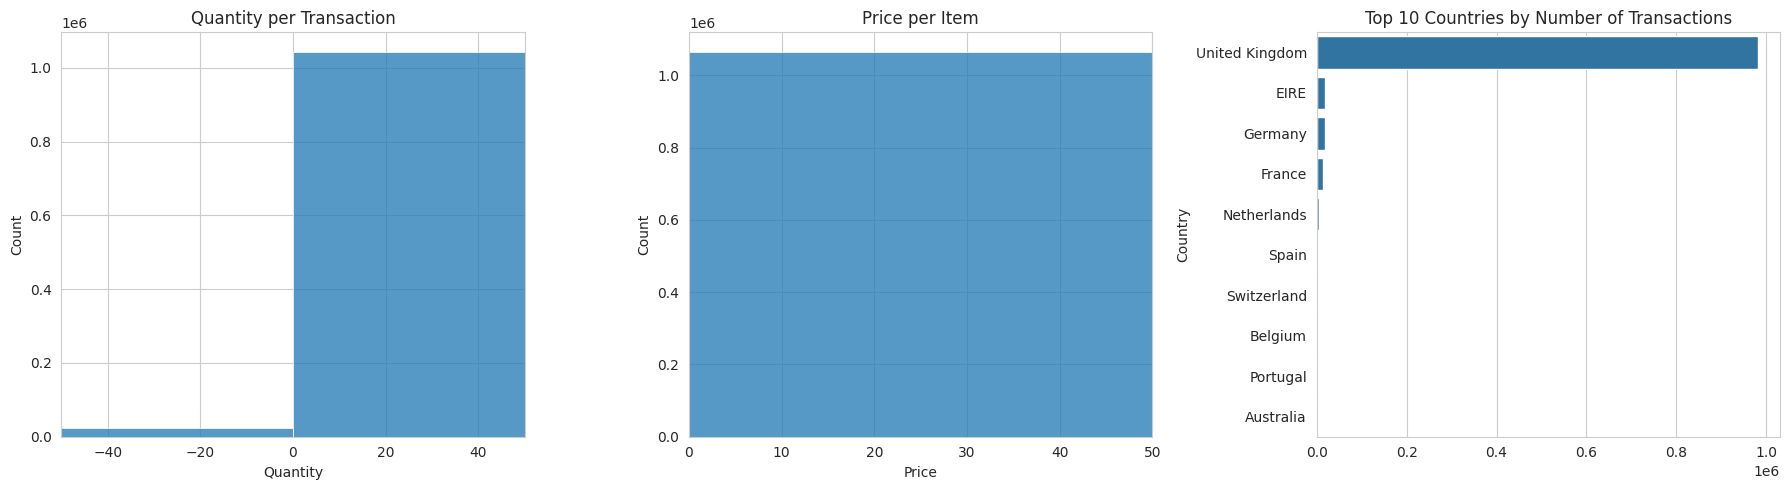

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df["Quantity"], bins=50, ax=axes[0])
axes[0].set_title("Quantity per Transaction")
axes[0].set_xlim(-50, 50)

sns.histplot(df["Price"], bins=50, ax=axes[1])
axes[1].set_title("Price per Item")
axes[1].set_xlim(0, 50)

top_countries = df["Country"].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, ax=axes[2])
axes[2].set_title("Top 10 Countries by Number of Transactions")

plt.tight_layout()
plt.show()


**The analysis above found several problems in the dataset:**



* 243 007 rows are missing a customer ID. These rows cannot be linked to a specific customer, so they cannot be used for customer analysis
* 34 335 rows duplicates
* 22 950 rows have negative quantities, which represent returned items
*   6 202 rows have a price of zero which may represent free items or promotions

# Phase 4: Data Cleaning

**Objective:** Fix the problems we found in Phase 3, so the data is ready to use.

In [8]:
df_clean = df.drop_duplicates()

# Rows with no Customer ID can't be tied to a customer profile, so they're
# dropped rather than imputed - segmentation and prediction happen at the
# customer level, not the transaction level.
df_clean = df_clean.dropna(subset=["Customer ID"])

df_clean["Customer ID"] = df_clean["Customer ID"].astype(int)
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])

print("Rows before cleaning:", df.shape[0])
print("Rows after cleaning:", df_clean.shape[0])
print("Rows removed:", df.shape[0] - df_clean.shape[0])


Rows before cleaning: 1067371
Rows after cleaning: 797885
Rows removed: 269486


After cleaning the data **269,486 rows** were removed in total, leaving **797,885 clean rows**.

The cleaned dataset stored as **'df_clean'**, is used for all feature engineering and machine learning that follows


# Phase 5: Feature Engineering

**Objective:** Create useful information from the transaction data that help understand each customer's shopping behaviour.

This phase covers four parts:
- **Total Amount** - how much each customer spent on each  transaction.
- **RFM Features** - how recently, how often, and how much each customer purchases.
- **Return Features** - information about a customer's return behaviour.
- **Churn Label** - whether a customer is considered to have stopped shopping.


### 5.1 TotalAmount

In [9]:
# Returns have a negative quantity, so TotalAmount is negative for them too.
df_clean["TotalAmount"] = df_clean["Quantity"] * df_clean["Price"]

df_clean[["Quantity", "Price", "TotalAmount"]].head()


,Quantity,Price,TotalAmount
0,12,6.95,83.4
1,12,6.75,81.0
2,12,6.75,81.0
3,48,2.10,100.8
4,24,1.25,30.0


### 5.2 RFM Features (Recency, Frequency, Monetary)

In [10]:
#Use the day after the last transaction as reference date
#This lets us calculate how many days ago each customer last purchased
analysis_date = df_clean["InvoiceDate"].max() + pd.Timedelta(days=1)
print("Analysis date:", analysis_date)


Analysis date: 2011-12-10 12:50:00


In [11]:
#Calculate each customer's Recency, Frequency, and Monentary Value(RFM)
last_purchase_date = df_clean.groupby("Customer ID")["InvoiceDate"].max()
recency = (analysis_date - last_purchase_date).dt.days

frequency = df_clean.groupby("Customer ID")["Invoice"].nunique()

monetary = df_clean.groupby("Customer ID")["TotalAmount"].sum()

rfm = pd.DataFrame({
    "Recency": recency,
    "Frequency": frequency,
    "Monetary": monetary
}).reset_index()

rfm.columns = ["CustomerID", "Recency", "Frequency", "Monetary"]

print("Number of customers:", rfm.shape[0])
rfm.head()


Number of customers: 5942


,CustomerID,Recency,Frequency,Monetary
0,12346,326,17,-51.74
1,12347,2,8,4921.53
2,12348,75,5,2019.40
3,12349,19,5,4404.54
4,12350,310,1,334.40


### 5.3 Return Features

In [12]:
#Identify returns and summarize each customer's return behaviour
returns = df_clean[df_clean["Quantity"] < 0]

return_transactions = returns.groupby("Customer ID")["Invoice"].nunique()
returned_quantity = returns.groupby("Customer ID")["Quantity"].sum()
return_amount = returns.groupby("Customer ID")["TotalAmount"].sum()

customer_returns = pd.DataFrame({
    "ReturnTransactions": return_transactions,
    "ReturnedQuantity": returned_quantity,
    "ReturnAmount": return_amount
}).reset_index()

customer_returns.columns = ["CustomerID", "ReturnTransactions", "ReturnedQuantity", "ReturnAmount"]

print("Customers with at least one return:", customer_returns.shape[0])
customer_returns.head()


Customers with at least one return: 2572


,CustomerID,ReturnTransactions,ReturnedQuantity,ReturnAmount
0,12346,5,-74232,-77608.20
1,12349,1,-5,-24.15
2,12352,3,-66,-960.63
3,12359,4,-226,-221.05
4,12360,1,-1,-40.00


### 5.4 Churn Label

In [13]:
# Churn = no purchase for more than 90 days. 1 = churned, 0 = active.
CHURN_THRESHOLD_DAYS = 90

rfm["Churn"] = (rfm["Recency"] > CHURN_THRESHOLD_DAYS).astype(int)

churn_counts = rfm["Churn"].value_counts()
churn_percent = (rfm["Churn"].value_counts(normalize=True) * 100).round(1)

pd.DataFrame({"Customers": churn_counts, "Percentage": churn_percent})


,Customers,Percentage
Churn,,
1,3024,50.9
0,2918,49.1


### 5.5 Bringing the Features Together

In [14]:
#Merge return information with RFM table
#Customers with no returns are given a value of 0
master_df = rfm.merge(customer_returns, on="CustomerID", how="left")

return_columns = ["ReturnTransactions", "ReturnedQuantity", "ReturnAmount"]
master_df[return_columns] = master_df[return_columns].fillna(0)

print("Master table shape:", master_df.shape)
master_df.head()


Master table shape: (5942, 8)


,CustomerID,Recency,Frequency,Monetary,Churn,ReturnTransactions,ReturnedQuantity,ReturnAmount
0,12346,326,17,-51.74,1,5.0,-74232.0,-77608.20
1,12347,2,8,4921.53,0,0.0,0.0,0.00
2,12348,75,5,2019.40,0,0.0,0.0,0.00
3,12349,19,5,4404.54,0,1.0,-5.0,-24.15
4,12350,310,1,334.40,1,0.0,0.0,0.00


The customer table contains **5,942 unique customers**. Using the 90-day rule, 50.9% are classified as churned and 49.1% as active.Around 43% of customers have made at least one return.

This table is the foundation for segmentation, churn prediction, and return prediction - all three are built from these same features.


# Phase 6: Feature Validation

**Objective:** Check whether the features we created look reasonable before using them for clustering and prediction

In [15]:
master_df[["Recency", "Frequency", "Monetary"]].describe()


,Recency,Frequency,Monetary
count,5942.000000,5942.000000,5942.000000
mean,202.908617,7.552339,2741.499712
std,211.857936,15.972262,13676.639629
min,1.000000,1.000000,-25111.090000
25%,25.000000,2.000000,321.065000
50%,96.000000,4.000000,822.010000
75%,381.000000,8.000000,2142.195000
max,739.000000,510.000000,570380.610000


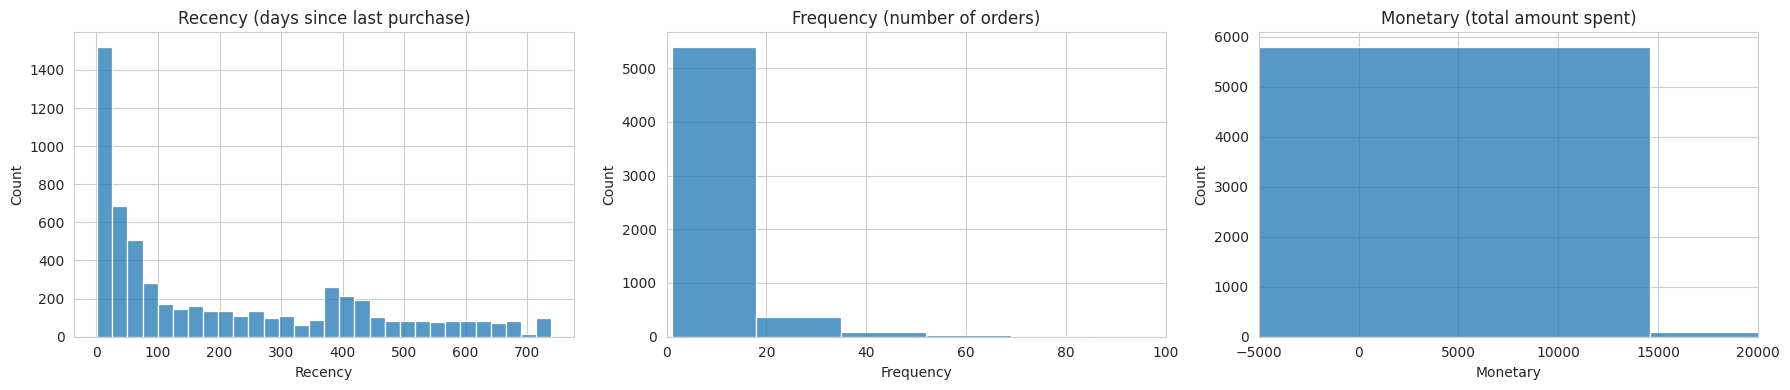

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.histplot(master_df["Recency"], bins=30, ax=axes[0])
axes[0].set_title("Recency (days since last purchase)")

sns.histplot(master_df["Frequency"], bins=30, ax=axes[1])
axes[1].set_title("Frequency (number of orders)")
axes[1].set_xlim(0, 100)

sns.histplot(master_df["Monetary"], bins=30, ax=axes[2])
axes[2].set_title("Monetary (total amount spent)")
axes[2].set_xlim(-5000, 20000)

plt.tight_layout()
plt.show()


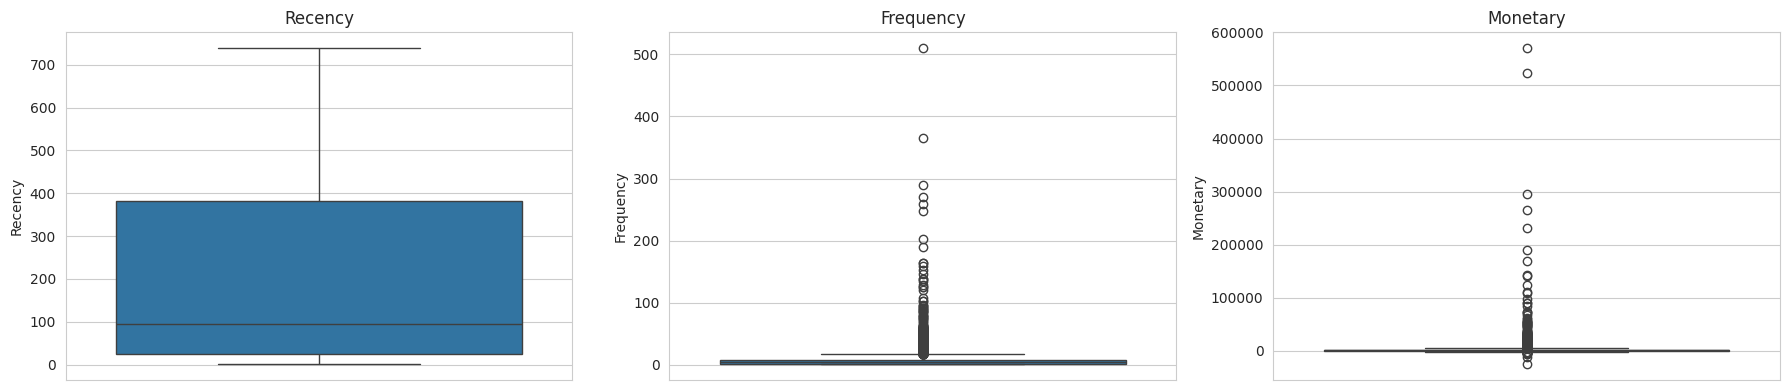

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.boxplot(y=master_df["Recency"], ax=axes[0])
axes[0].set_title("Recency")

sns.boxplot(y=master_df["Frequency"], ax=axes[1])
axes[1].set_title("Frequency")

sns.boxplot(y=master_df["Monetary"], ax=axes[2])
axes[2].set_title("Monetary")

plt.tight_layout()
plt.show()


Recency averages 203 days but the median is 96 - most customers bought fairly recently, while a long tail has been inactive for up to 739 days. Frequency is similarly skewed: a median of 4 orders against a maximum of 510. Monetary ranges from -£25,111 (customers who returned more than they purchased) up to £570,380, with a median of £822.

These extreme values matter for K-Means specifically, since it's sensitive to scale and outliers - a handful of very high-frequency, high-spend customers can pull cluster centres away from what's typical, so this is worth keeping in mind when interpreting the segments.


# Phase 7: Customer Segmentation

**Objective:** Group customers into segments based on their shopping behaviour, using K-Means clustering on the RFM features.

### 7.1 Scale the Features

In [18]:
# K-Means uses distance, so features need to be on the same scale - without
# this, Monetary (which ranges into the hundreds of thousands) would dominate
# the distance calculation over Recency and Frequency.
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(master_df[["Recency", "Frequency", "Monetary"]])
rfm_scaled = pd.DataFrame(rfm_scaled, columns=["Recency", "Frequency", "Monetary"])

rfm_scaled.describe().round(2)


,Recency,Frequency,Monetary
count,5942.00,5942.00,5942.00
mean,0.00,0.00,-0.00
std,1.00,1.00,1.00
min,-0.95,-0.41,-2.04
25%,-0.84,-0.35,-0.18
50%,-0.50,-0.22,-0.14
75%,0.84,0.03,-0.04
max,2.53,31.46,41.51


### 7.2 Choose the Number of Clusters

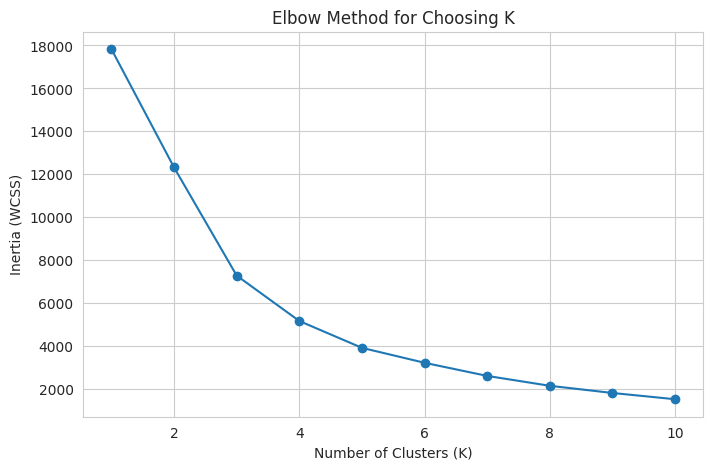

In [19]:
# Elbow method: fit K-Means for K = 1 to 10 and look for the point where
# adding more clusters stops reducing inertia by much.
inertia_scores = []
k_values = range(1, 11)

for k in k_values:
    kmeans_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_test.fit(rfm_scaled)
    inertia_scores.append(kmeans_test.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia_scores, marker="o")
plt.title("Elbow Method for Choosing K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (WCSS)")
plt.show()


Observation: The within-cluster variation decreases substantially up to K=4, after which the improvement becomes smaller. Based on the elbow plot, K=4 was selected for the customer segmentation.

### 7.3 Train the K-Means Model

In [20]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
master_df["Cluster"] = kmeans.fit_predict(rfm_scaled)

master_df["Cluster"].value_counts().sort_index()


,count
Cluster,
0,2037
1,3859
2,4
3,42


### 7.4 Understand What Each Cluster Looks Like

In [21]:
# Average RFM values per cluster, plus cluster sizes - this is what tells us
# what each cluster actually represents.
cluster_profile = master_df.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean().round(1)
cluster_profile["Number of Customers"] = master_df["Cluster"].value_counts().sort_index()

cluster_profile


,Recency,Frequency,Monetary,Number of Customers
Cluster,,,,
0,466.3,2.6,606.5,2037
1,66.1,8.7,2749.9,3859
2,3.5,257.2,413886.0,4
3,20.1,120.6,66361.5,42


In [22]:
# Names based on the profile above, so results are easier to read and explain.
cluster_names = {
    0: "At-Risk / Lapsing Customers",
    1: "Core Customers",
    2: "Top-Tier Outlier Customers",
    3: "High-Value Loyal Customers"
}

master_df["CustomerSegment"] = master_df["Cluster"].map(cluster_names)

master_df["CustomerSegment"].value_counts()


,count
CustomerSegment,
Core Customers,3859
At-Risk / Lapsing Customers,2037
High-Value Loyal Customers,42
Top-Tier Outlier Customers,4


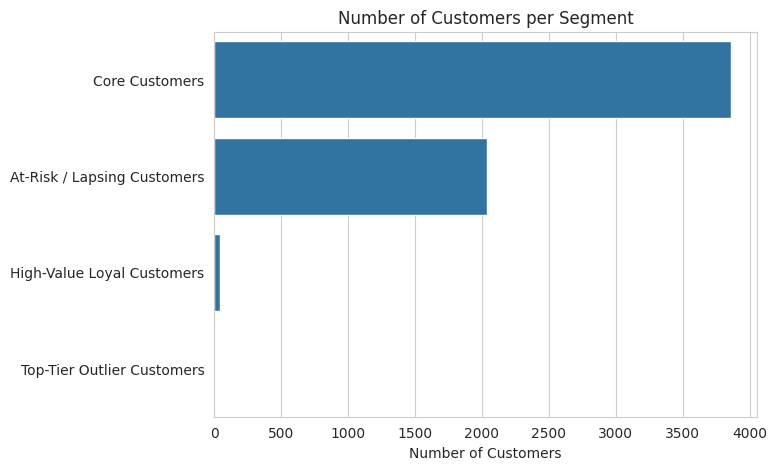

In [23]:
plt.figure(figsize=(7, 5))
sns.countplot(data=master_df, y="CustomerSegment",
              order=master_df["CustomerSegment"].value_counts().index)
plt.title("Number of Customers per Segment")
plt.xlabel("Number of Customers")
plt.ylabel("")
plt.show()


The four segments are uneven in size:

- **Core Customers (3,859, 65%)** - shop fairly often and recently, moderate spend.
- **At-Risk / Lapsing Customers (2,037, 34%)** - haven't purchased in over a year on average, low spend.
- **High-Value Loyal Customers (42)** - shop very often and spend a lot.
- **Top-Tier Outlier Customers (4)** - an extreme group spending hundreds of thousands of pounds, almost certainly wholesale or business accounts rather than typical shoppers.

Two clusters are tiny and driven by a small number of high-spending customers. They're still worth treating separately since they likely need different strategies, but the imbalance is something to keep in mind when interpreting the segmentation.


# Phase 8: Churn Prediction

**Objective:** Predict which customers are likely to stop shopping.

**Why Recency is excluded:** Churn is based on Recency, where more than 90 days means a customer is considered churned. We therefore leave Recency out of the model so it does not simply learn this rule.

**Why customer segments need care:** `CustomerSegment` are used, but with caution because they were created using Recency, Frequency, and Monetary value.

The model uses Frequency, Monetary value, return behaviour, and CustomerSegment to predict churn.


### 8.1 Prepare the Features

In [24]:
# Recency and Churn are dropped (see note above); CustomerID and Cluster
# aren't predictive features either.
churn_features = master_df.drop(columns=["CustomerID", "Recency", "Churn", "Cluster"])
churn_features = pd.get_dummies(churn_features, columns=["CustomerSegment"], drop_first=True)

X_churn = churn_features
y_churn = master_df["Churn"]

X_churn.columns.tolist()


['Frequency',
 'Monetary',
 'ReturnTransactions',
 'ReturnedQuantity',
 'ReturnAmount',
 'CustomerSegment_Core Customers',
 'CustomerSegment_High-Value Loyal Customers',
 'CustomerSegment_Top-Tier Outlier Customers']

### 8.2 Split the Data into Training and Testing Sets

In [25]:
X_train_churn, X_test_churn, y_train_churn, y_test_churn = train_test_split(
    X_churn, y_churn,
    test_size=0.2,
    random_state=42,
    stratify=y_churn
)

print("Training customers:", X_train_churn.shape[0])
print("Testing customers:", X_test_churn.shape[0])


Training customers: 4753
Testing customers: 1189


### 8.3 Scale the Numeric Features

In [26]:
# Logistic Regression is distance/gradient-based and sensitive to feature
# scale, so its inputs are standardised. Decision Tree and Random Forest
# split on thresholds regardless of scale, so they use the unscaled features.
churn_numeric_columns = ["Frequency", "Monetary", "ReturnTransactions", "ReturnedQuantity", "ReturnAmount"]

churn_scaler = StandardScaler()

X_train_churn_scaled = X_train_churn.copy()
X_test_churn_scaled = X_test_churn.copy()

X_train_churn_scaled[churn_numeric_columns] = churn_scaler.fit_transform(X_train_churn[churn_numeric_columns])
X_test_churn_scaled[churn_numeric_columns] = churn_scaler.transform(X_test_churn[churn_numeric_columns])


### 8.4 Train the Models

In [27]:
# Baseline model for comparison against the tree-based models.
log_reg_churn = LogisticRegression(max_iter=1000, random_state=42)
log_reg_churn.fit(X_train_churn_scaled, y_train_churn)
log_reg_churn_preds = log_reg_churn.predict(X_test_churn_scaled)


In [28]:
# Depth capped at 6 to limit overfitting.
tree_churn = DecisionTreeClassifier(max_depth=6, random_state=42)
tree_churn.fit(X_train_churn, y_train_churn)
tree_churn_preds = tree_churn.predict(X_test_churn)


In [29]:
# Ensemble of 300 trees, generally more robust than a single tree.
forest_churn = RandomForestClassifier(n_estimators=300, random_state=42)
forest_churn.fit(X_train_churn, y_train_churn)
forest_churn_preds = forest_churn.predict(X_test_churn)


### 8.5 Compare the Models

In [30]:
def get_scores(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-Score": f1_score(y_true, y_pred)
    }

churn_comparison = pd.DataFrame({
    "Logistic Regression": get_scores(y_test_churn, log_reg_churn_preds),
    "Decision Tree": get_scores(y_test_churn, tree_churn_preds),
    "Random Forest": get_scores(y_test_churn, forest_churn_preds)
}).T.round(3)

churn_comparison


,Accuracy,Precision,Recall,F1-Score
Logistic Regression,0.836,1.000,0.678,0.808
Decision Tree,0.828,0.963,0.689,0.803
Random Forest,0.793,0.822,0.757,0.788


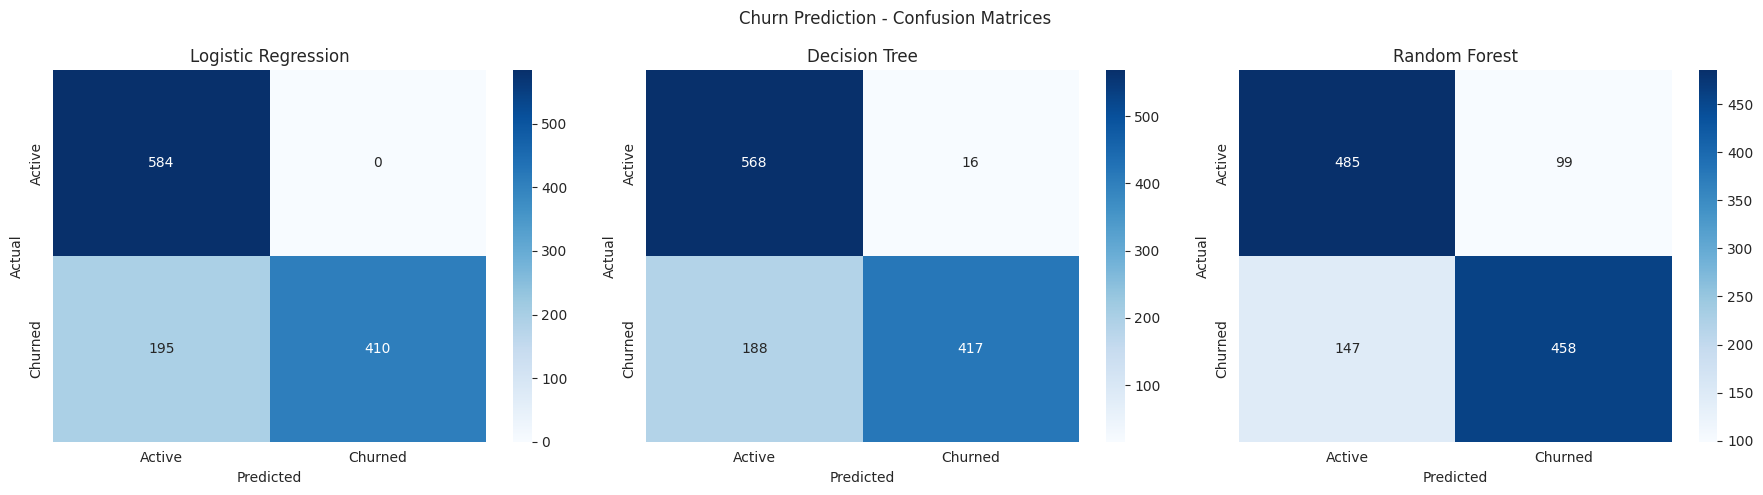

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

model_predictions = {
    "Logistic Regression": log_reg_churn_preds,
    "Decision Tree": tree_churn_preds,
    "Random Forest": forest_churn_preds
}

for ax, (name, preds) in zip(axes, model_predictions.items()):
    matrix = confusion_matrix(y_test_churn, preds)
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Active", "Churned"], yticklabels=["Active", "Churned"])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Churn Prediction - Confusion Matrices")
plt.tight_layout()
plt.show()


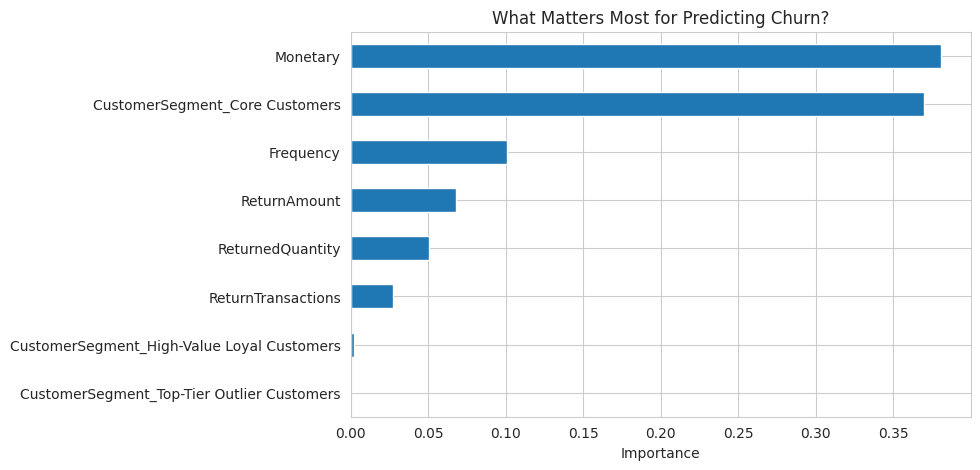

In [32]:
feature_importance_churn = pd.Series(
    forest_churn.feature_importances_,
    index=X_train_churn.columns
).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
feature_importance_churn.plot(kind="barh")
plt.title("What Matters Most for Predicting Churn?")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()


All three models land in the 70-80% accuracy range. Logistic Regression is better at identifying active customers but misses more churned ones; Random Forest catches more churned customers (75.7% recall) at the cost of more false positives. Monetary and CustomerSegment come out as the most important features for Random Forest.

CustomerSegment's importance needs the caveat raised above: since segments were built partly from Recency, and Churn is defined by Recency, this feature is likely picking up Recency indirectly rather than contributing an entirely independent signal. The genuinely new information in this model comes from Frequency, Monetary, and return behaviour - CustomerSegment's ranking should be read with that in mind, not treated as proof the segments predict churn on their own merits.


# Phase 9: Return Prediction

**Objective:** Build a model to predict which customers are likely to return items.

**Why return features are excluded:** `HasReturned` (the target) is derived directly from `ReturnTransactions`, so `ReturnTransactions`, `ReturnedQuantity`, and `ReturnAmount` are dropped as predictors - including them would mean the model is just reading off its own label. The model instead uses Recency, Frequency, Monetary, Churn, and customer segment.


### 9.1 Define the Return Target

In [33]:
# A customer "has returned" if they have at least one return transaction
master_df["HasReturned"] = (master_df["ReturnTransactions"] > 0).astype(int)

return_counts = master_df["HasReturned"].value_counts()
return_percent = (master_df["HasReturned"].value_counts(normalize=True) * 100).round(1)

pd.DataFrame({"Customers": return_counts, "Percentage": return_percent})


,Customers,Percentage
HasReturned,,
0,3370,56.7
1,2572,43.3


### 9.2 Prepare the Features

In [34]:
# Return columns are dropped since they define HasReturned directly (see
# note above); CustomerID and Cluster aren't predictive features either.
return_features = master_df.drop(columns=[
    "CustomerID", "ReturnTransactions", "ReturnedQuantity", "ReturnAmount", "HasReturned", "Cluster"
])

return_features = pd.get_dummies(return_features, columns=["CustomerSegment"], drop_first=True)

X_return = return_features
y_return = master_df["HasReturned"]

X_return.columns.tolist()


['Recency',
 'Frequency',
 'Monetary',
 'Churn',
 'CustomerSegment_Core Customers',
 'CustomerSegment_High-Value Loyal Customers',
 'CustomerSegment_Top-Tier Outlier Customers']

### 9.3 Split, Scale and Train

In [35]:
X_train_return, X_test_return, y_train_return, y_test_return = train_test_split(
    X_return, y_return,
    test_size=0.2,
    random_state=42,
    stratify=y_return
)

print("Training customers:", X_train_return.shape[0])
print("Testing customers:", X_test_return.shape[0])


Training customers: 4753
Testing customers: 1189


In [36]:
# Same scaling logic as Phase 8 - only Logistic Regression needs it.
return_numeric_columns = ["Recency", "Frequency", "Monetary"]

return_scaler = StandardScaler()

X_train_return_scaled = X_train_return.copy()
X_test_return_scaled = X_test_return.copy()

X_train_return_scaled[return_numeric_columns] = return_scaler.fit_transform(X_train_return[return_numeric_columns])
X_test_return_scaled[return_numeric_columns] = return_scaler.transform(X_test_return[return_numeric_columns])


In [37]:
log_reg_return = LogisticRegression(max_iter=1000, random_state=42)
log_reg_return.fit(X_train_return_scaled, y_train_return)
log_reg_return_preds = log_reg_return.predict(X_test_return_scaled)


In [38]:
tree_return = DecisionTreeClassifier(max_depth=6, random_state=42)
tree_return.fit(X_train_return, y_train_return)
tree_return_preds = tree_return.predict(X_test_return)


In [39]:
forest_return = RandomForestClassifier(n_estimators=300, random_state=42)
forest_return.fit(X_train_return, y_train_return)
forest_return_preds = forest_return.predict(X_test_return)


### 9.4 Compare the Models

In [40]:
return_comparison = pd.DataFrame({
    "Logistic Regression": get_scores(y_test_return, log_reg_return_preds),
    "Decision Tree": get_scores(y_test_return, tree_return_preds),
    "Random Forest": get_scores(y_test_return, forest_return_preds)
}).T.round(3)

return_comparison


,Accuracy,Precision,Recall,F1-Score
Logistic Regression,0.765,0.812,0.594,0.686
Decision Tree,0.786,0.744,0.769,0.756
Random Forest,0.791,0.757,0.761,0.759


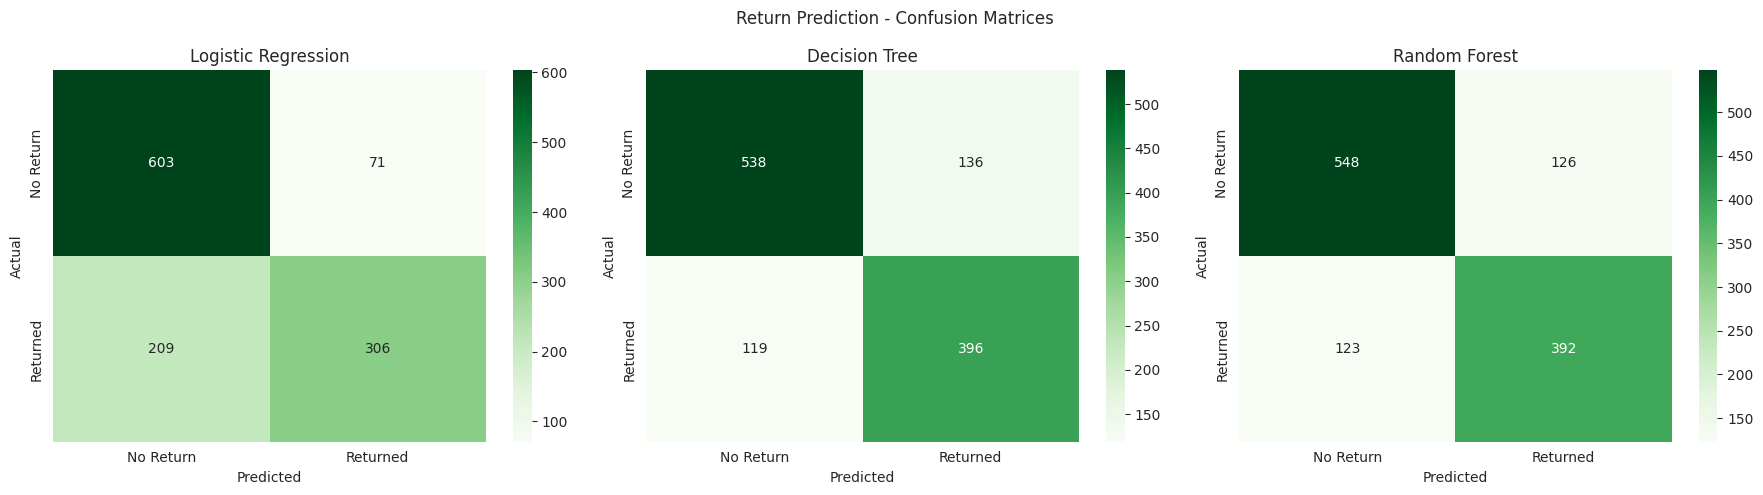

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

return_predictions = {
    "Logistic Regression": log_reg_return_preds,
    "Decision Tree": tree_return_preds,
    "Random Forest": forest_return_preds
}

for ax, (name, preds) in zip(axes, return_predictions.items()):
    matrix = confusion_matrix(y_test_return, preds)
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Greens", ax=ax,
                xticklabels=["No Return", "Returned"], yticklabels=["No Return", "Returned"])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Return Prediction - Confusion Matrices")
plt.tight_layout()
plt.show()


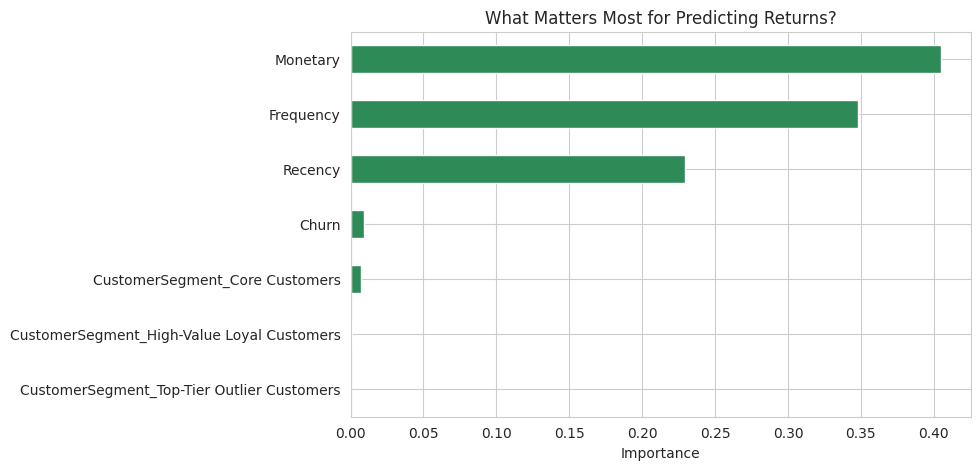

In [42]:
feature_importance_return = pd.Series(
    forest_return.feature_importances_,
    index=X_train_return.columns
).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
feature_importance_return.plot(kind="barh", color="seagreen")
plt.title("What Matters Most for Predicting Returns?")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()


About 43% of customers have returned at least one item. Random Forest and Decision Tree correctly identify around 76% of returners; Logistic Regression trails behind. Monetary and Frequency are the strongest predictors here - unlike the churn model, return behaviour is tied to how customers shop rather than which segment they fall into, so there's no equivalent leakage concern with CustomerSegment in this model.


# Phase 10: Model Evaluation

**Objective:** Compare all six models side by side, to see which ones work best and whether we've met the proposal's targets.

In [43]:
overall_comparison = pd.concat(
    [churn_comparison.add_suffix(" (Churn)"), return_comparison.add_suffix(" (Return)")],
    axis=1
)

overall_comparison


,Accuracy (Churn),Precision (Churn),Recall (Churn),F1-Score (Churn),Accuracy (Return),Precision (Return),Recall (Return),F1-Score (Return)
Logistic Regression,0.836,1.000,0.678,0.808,0.765,0.812,0.594,0.686
Decision Tree,0.828,0.963,0.689,0.803,0.786,0.744,0.769,0.756
Random Forest,0.793,0.822,0.757,0.788,0.791,0.757,0.761,0.759


Scores mostly sit between 75% and 84% across both tasks. Logistic Regression has the highest precision (fewer false positives) but misses more actual cases; Random Forest and Decision Tree catch more true positives at the cost of more false alarms. For a first version, this is a reasonable baseline - next steps would include handling the Monetary outliers, and testing different hyperparameters or feature sets.


# Phase 10b: Supplementary Tables and Charts Used in the Report

**Objective:** Produce the extra charts and tables that appear in the final report (distribution charts, descriptive statistics, segment cross-tabulations, feature-importance tables, confusion-matrix counts and a model-settings summary). Run this phase after Phase 10, because it uses variables created in Phases 5 to 9.

### 10b.1 Distribution of Churn Status and Return Behaviour (Figures 6.2 and 6.3)

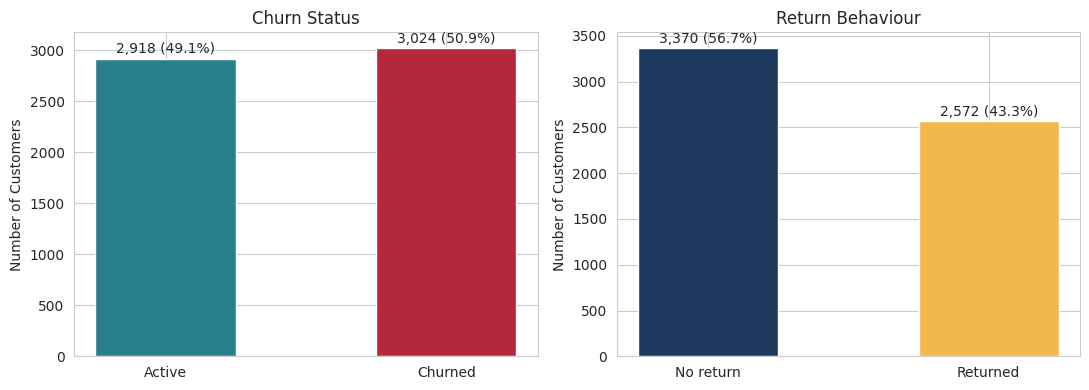

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

churn_plot = master_df["Churn"].map({0: "Active", 1: "Churned"}).value_counts().reindex(["Active", "Churned"])
axes[0].bar(churn_plot.index, churn_plot.values, color=["#2A7F8E", "#B5273A"], width=0.5)
axes[0].set_title("Churn Status")
axes[0].set_ylabel("Number of Customers")

return_plot = master_df["HasReturned"].map({0: "No return", 1: "Returned"}).value_counts().reindex(["No return", "Returned"])
axes[1].bar(return_plot.index, return_plot.values, color=["#1F3A5F", "#F2B84B"], width=0.5)
axes[1].set_title("Return Behaviour")
axes[1].set_ylabel("Number of Customers")

for ax, series in zip(axes, [churn_plot, return_plot]):
    for i, v in enumerate(series.values):
        ax.text(i, v + 50, f"{v:,} ({v / len(master_df) * 100:.1f}%)", ha="center")

plt.tight_layout()
plt.show()

### 10b.2 Descriptive Statistics of the Final Customer Data (Section 6.1)

In [45]:
stats = master_df[["Recency", "Frequency", "Monetary"]].describe().T
stats["median"] = master_df[["Recency", "Frequency", "Monetary"]].median()
stats.round(1)

,count,mean,std,min,25%,50%,75%,max,median
Recency,5942.0,202.9,211.9,1.0,25.0,96.0,381.0,739.0,96.0
Frequency,5942.0,7.6,16.0,1.0,2.0,4.0,8.0,510.0,4.0
Monetary,5942.0,2741.5,13676.6,-25111.1,321.1,822.0,2142.2,570380.6,822.0


### 10b.3 Churn and Return Behaviour by Customer Segment (Section 6.4.3)

In [46]:
# Counts and row percentages: how churn and returns are distributed across the four segments.
churn_by_segment = pd.crosstab(master_df["CustomerSegment"], master_df["Churn"].map({0: "Active", 1: "Churned"}))
churn_by_segment_pct = (pd.crosstab(master_df["CustomerSegment"], master_df["Churn"].map({0: "Active", 1: "Churned"}), normalize="index") * 100).round(1)

return_by_segment = pd.crosstab(master_df["CustomerSegment"], master_df["HasReturned"].map({0: "No return", 1: "Returned"}))
return_by_segment_pct = (pd.crosstab(master_df["CustomerSegment"], master_df["HasReturned"].map({0: "No return", 1: "Returned"}), normalize="index") * 100).round(1)

print("Churn by segment (counts)");   display(churn_by_segment)
print("Churn by segment (row %)");    display(churn_by_segment_pct)
print("Returns by segment (counts)"); display(return_by_segment)
print("Returns by segment (row %)");  display(return_by_segment_pct)

Churn by segment (counts)


Churn,Active,Churned
CustomerSegment,,
At-Risk / Lapsing Customers,0,2037
Core Customers,2874,985
High-Value Loyal Customers,40,2
Top-Tier Outlier Customers,4,0


Churn by segment (row %)


Churn,Active,Churned
CustomerSegment,,
At-Risk / Lapsing Customers,0.0,100.0
Core Customers,74.5,25.5
High-Value Loyal Customers,95.2,4.8
Top-Tier Outlier Customers,100.0,0.0


Returns by segment (counts)


HasReturned,No return,Returned
CustomerSegment,,
At-Risk / Lapsing Customers,1456,581
Core Customers,1914,1945
High-Value Loyal Customers,0,42
Top-Tier Outlier Customers,0,4


Returns by segment (row %)


HasReturned,No return,Returned
CustomerSegment,,
At-Risk / Lapsing Customers,71.5,28.5
Core Customers,49.6,50.4
High-Value Loyal Customers,0.0,100.0
Top-Tier Outlier Customers,0.0,100.0


### 10b.4 Feature Importance Tables (Table 6.5)

In [47]:
print("Churn model - Random Forest feature importance")
display(feature_importance_churn.round(3).to_frame("Importance"))

print("Return model - Random Forest feature importance")
display(feature_importance_return.round(3).to_frame("Importance"))

Churn model - Random Forest feature importance


,Importance
Monetary,0.381
CustomerSegment_Core Customers,0.370
Frequency,0.101
ReturnAmount,0.068
ReturnedQuantity,0.051
ReturnTransactions,0.027
CustomerSegment_High-Value Loyal Customers,0.002
CustomerSegment_Top-Tier Outlier Customers,0.000


Return model - Random Forest feature importance


,Importance
Monetary,0.405
Frequency,0.348
Recency,0.229
Churn,0.009
CustomerSegment_Core Customers,0.007
CustomerSegment_High-Value Loyal Customers,0.001
CustomerSegment_Top-Tier Outlier Customers,0.000


### 10b.5 Confusion-Matrix Counts (Figures 6.7 and 6.8)

In [48]:
def cm_table(y_true, preds_dict, labels):
    rows = []
    for name, preds in preds_dict.items():
        tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
        rows.append({"Model": name, f"True {labels[0]}": tn, f"False {labels[1]}": fp,
                     f"False {labels[0]}": fn, f"True {labels[1]}": tp})
    return pd.DataFrame(rows).set_index("Model")

print("Churn prediction (test set)")
display(cm_table(y_test_churn, model_predictions, ["Active", "Churned"]))

print("Return prediction (test set)")
display(cm_table(y_test_return, return_predictions, ["No Return", "Returned"]))

Churn prediction (test set)


,True Active,False Churned,False Active,True Churned
Model,,,,
Logistic Regression,584,0,195,410
Decision Tree,568,16,188,417
Random Forest,485,99,147,458


Return prediction (test set)


,True No Return,False Returned,False No Return,True Returned
Model,,,,
Logistic Regression,603,71,209,306
Decision Tree,538,136,119,396
Random Forest,548,126,123,392


### 10b.6 Data-Quality Summary and Final Model Settings (Tables 5.1 and 6.6)

In [49]:
data_quality = pd.DataFrame({
    "Rows affected": [df["Customer ID"].isnull().sum(), df.duplicated().sum(), (df["Quantity"] < 0).sum(),
                      (df["Price"] == 0).sum(), df["Description"].isnull().sum()]
}, index=["Missing Customer ID", "Duplicate rows", "Negative quantity (returns)", "Price of zero", "Missing Description"])
data_quality["Treatment"] = ["Removed", "Removed", "Kept (used for return features)", "Kept", "Kept (not used)"]
display(data_quality)

model_settings = pd.DataFrame({
    "Settings": [
        "StandardScaler on RFM; n_clusters=4; n_init=10; random_state=42",
        "max_iter=1000; random_state=42; standardised numeric inputs",
        "max_depth=6; random_state=42; criterion='gini' (default); unscaled",
        "n_estimators=300; random_state=42; unscaled"]
}, index=["K-Means", "Logistic Regression", "Decision Tree", "Random Forest"])
display(model_settings)

,Rows affected,Treatment
Missing Customer ID,243007,Removed
Duplicate rows,34335,Removed
Negative quantity (returns),22950,Kept (used for return features)
Price of zero,6202,Kept
Missing Description,4382,Kept (not used)


,Settings
K-Means,StandardScaler on RFM; n_clusters=4; n_init=10...
Logistic Regression,max_iter=1000; random_state=42; standardised n...
Decision Tree,max_depth=6; random_state=42; criterion='gini'...
Random Forest,n_estimators=300; random_state=42; unscaled


# Phase 11: Business Insights

**Objective:** Use the results to suggest actions that a retailer can take.

**Segments.**

Most customers are Core Customers (65%), who buy fairly regularly. About 34% are At-Risk Customers, who have not purchased for a long time. There are also 46 high-value customers who spend much more than the typical customer.

**Churn.**

About half of the customers are classified as churned. Most of these customers are in the At-Risk segment. Random Forest was useful for finding customers who may leave because it identified more of the customers who actually churned.

**Returns.**

About 43% of customers have returned an item. Customers who buy more often and spend more also tend to have more returns.


**Recommendations:**
- **At-Risk Customers:** Send reminders, special offers, or discounts to encourage them to shop again.
- **Core Customers:** Keep them engaged through regular offers and good customer service because they make up the largest customer group.
- **High-Value Customers:** Give these customers extra attention because a small number of customers contribute a large amount of spending.
- **Customers with high return activity:** Investigate why these customers return items, especially among frequent and high-spending customers. This could help identify problems with products, sizing, or customer expectations.


**Honest limitations, worth stating in the final report:**

1. Monetary contains extreme values, including negative ones from customers who returned more than they purchased. These outliers can pull K-Means cluster centres away from what's typical for most customers. Future work could test outlier handling or a transformation (e.g. log scale) before clustering.
2. Recency isn't used directly in the churn model, but CustomerSegment is - and segments were built partly from Recency. So CustomerSegment's predictive value in the churn model is likely, in part, a proxy for Recency rather than fully independent information. This is a genuine limitation of the feature set, not just a footnote.
3. Accuracy sits around 75-85% across models. There's room to improve this further through hyperparameter tuning, cross-validation, or trying additional model types.


# Conclusion

This project combined customer segmentation, churn prediction, and return prediction using online retail data.

The analysis identified four customer groups and showed that about half of the customers were classified as churned. The machine learning models achieved reasonable results, with performance generally between 75% and 85%.

The results also showed that purchase frequency and spending were important in understanding customer behaviour. The findings were used to suggest actions such as retention campaigns for at-risk customers and closer monitoring of high-value customers.

The main areas for future improvement are handling extreme spending values and improving the prediction models through further tuning.
